# Multi-Model AutoML LOOCV Pipeline — FC node strength (SHAP Top-2)

`automl_comparison_paired_FC_ROI_strength.ipynb`와 **동일한 파이프라인**이다.
뇌 피처만 **선행연구 기반 4개 → SHAP 상위 2개**로 교체했다.

- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + FC node strength **2개** (Residualized)
- **제거 변수**: age, sex, mean_fd  /  **타겟**: vas_t1  /  **n = 44**

## 뇌 피처 선정 — SHAP 상위 2개

`automl_comparison_paired_FC_all_SHAP_bg43.ipynb`에서 FC strength 84개를 전부 넣고
5개 모델(Linear / ElasticNet / RF / XGBoost / SVR-RBF)의 fold별 local SHAP을 모은 결과,
임상 변수(`vas_t0`, `treatment_group`)를 제외한 상위 뇌 피처는:

| 순위 | Feature | SHAP 비중 | held-out 44명 중 local top-5 진입 |
|---:|---|---:|---:|
| 1 | `rh_Pallidum_fc` | 4.76% | 21/44 |
| 2 | `lh_cuneus_fc`   | 2.72% | 13/44 |

불안정한 LinearRegression을 제외한 4개 모델(ElasticNet, SVR-RBF, RF, XGBoost)의
상위 10위에 모두 든 뇌 피처는 `rh_Pallidum_fc` 하나뿐이고,
`lh_cuneus_fc`는 3개 모델에서 공통이었다.

## 주의 — 이 분석은 탐색적이다 (feature-selection leakage)

`rh_Pallidum_fc`, `lh_cuneus_fc`는 **같은 44명**의 SHAP으로 골람다.
따라서 여기서 성능이 좋아져도 unbiased validation이 아니다.
독립 표본에서 재현되기 전에는 "이 두 영역이 예측에 기여한다"고 결론내지 말 것.
bg43 노트북의 Top6 후속 실험도 같은 한계를 갖는다(RID 20 한 명에 크게 의존).

## 비교 대상

| 노트북 | 뇌 피처 |
|---|---|
| `..._FC_ROI_strength` | 선행연구 대응 4개 (OFC L/R, R caudal ACC, L bankssts) |
| `..._FC_all_SHAP_bg43` (Top6) | SHAP 상위 6개, RBF-SVR만 |
| **이 노트북** | **SHAP 상위 2개, 6개 모델 전부** |


In [20]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [21]:
# ==========================================================
# 1. DATA PREPARATION  (FC node strength)
# ==========================================================
df = pd.read_csv('fc_strength_68_16.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# SHAP 상위 2개 (automl_comparison_paired_FC_all_SHAP_bg43.ipynb 결과)
#   rh_Pallidum_fc : SHAP 비중 4.76%, 44명 중 21명에서 local SHAP 상위 5위
#   lh_cuneus_fc   : SHAP 비중 2.72%, 44명 중 13명에서 local SHAP 상위 5위
# 주의: 같은 44명의 SHAP으로 고른 피처이므로 이 결과는 탐색적이다 (selection leakage).
brain_features = [
    'rh_Pallidum_fc',
    'lh_cuneus_fc',
]

missing = [c for c in brain_features if c not in df.columns]
assert not missing, f'컬럼 없음: {missing}'

nuisance_covariates = ['age', 'sex', 'mean_fd']    # morph의 eTIV 자리를 mean_fd가 대체
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_brain = df[brain_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

print(f'n = {len(df)},  brain features = {X_brain.shape[1]}')
print(brain_features)


n = 44,  brain features = 2
['rh_Pallidum_fc', 'lh_cuneus_fc']


In [22]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# [변경] Baseline 항목 삭제. 모든 모델이 두 데이터셋에 동일하게 적용됨.
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=45면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [23]:
X_brain.shape

(44, 2)

In [24]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_brain)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_b_train, X_b_test = X_brain[train_idx], X_brain[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_b_train)
    X_b_train_clean = X_b_train - nuisance_regressor.predict(X_n_train)
    X_b_test_clean = X_b_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack ---
    X_train_full = np.hstack([X_b_train_clean, X_c_train]) # brain 2개 + clinical 2
    X_test_full = np.hstack([X_b_test_clean, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3, # nested CV 최적은 결국 mse 기준으로 선택됨
                                    scoring='neg_mean_squared_error', n_jobs=1)
            inner_cv.fit(X_tr, y_train) 
            pred = inner_cv.best_estimator_.predict(X_te) # 외부 테스트
            predictions[(dt, name)].append(pred[0]) # 예측값 저장
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...

Processing fold 44/44...

LOOCV Completed.


In [25]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })
    

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함

n_pos = int((pivot['dRMSE'] > 0).sum())  
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.309
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,1.888663,1.996230,0.107567
LinearRegression,1.925606,1.997338,0.071731
RandomForest,2.263331,2.200693,-0.062637
SVR_Linear,1.907703,2.040615,0.132912
SVR_RBF,2.125703,2.208213,0.082510
XGBoost,2.297771,2.235297,-0.062474



부호 일관성: 6개 중 4개가 +
  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.
  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,1.888663,0.299651,0.550946,0.000106
1,Clinical_ONLY,ElasticNet,1.996230,0.217604,0.477844,0.001037
6,Brain_Plus_Clinical,LinearRegression,1.925606,0.271985,0.541812,0.000146
0,Clinical_ONLY,LinearRegression,1.997338,0.216736,0.478364,0.001022
10,Brain_Plus_Clinical,RandomForest,2.263331,-0.005776,0.285705,0.060109
4,Clinical_ONLY,RandomForest,2.200693,0.049123,0.327847,0.029816
8,Brain_Plus_Clinical,SVR_Linear,1.907703,0.285459,0.554528,0.000094
2,Clinical_ONLY,SVR_Linear,2.040615,0.182425,0.449354,0.002214
9,Brain_Plus_Clinical,SVR_RBF,2.125703,0.112822,0.411962,0.005460
3,Clinical_ONLY,SVR_RBF,2.208213,0.042613,0.347018,0.021009


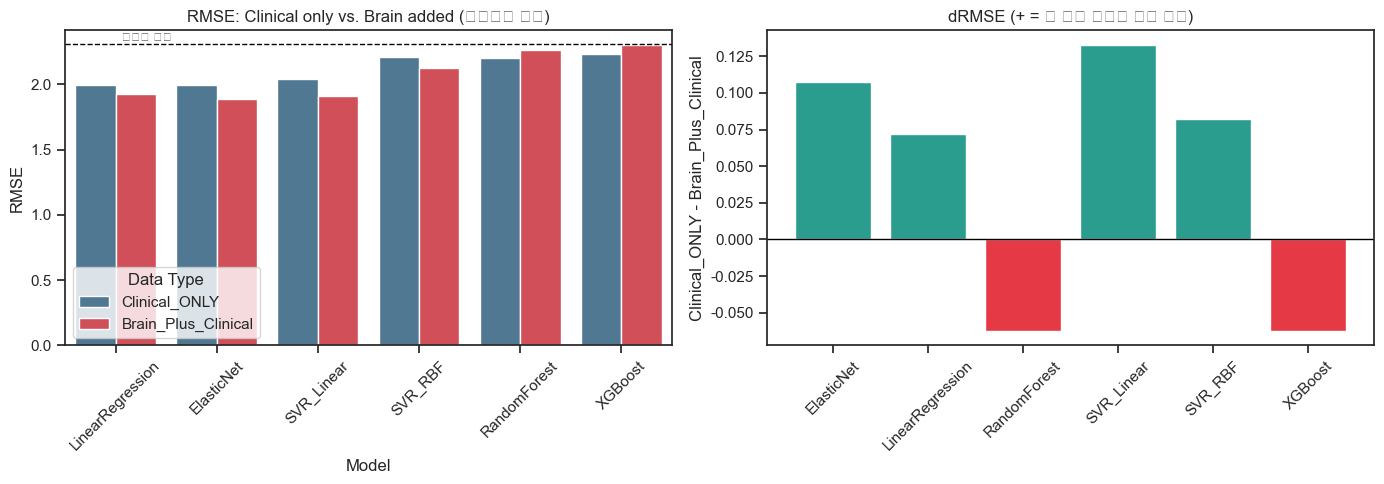

In [26]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[SVR_Linear / Clinical_ONLY] 고유 조합 12개, 최빈 43%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 7개, 최빈 84%
[RandomForest / Clinical_ONLY] 고유 조합 5개, 최빈 61%
[XGBoost / Clinical_ONLY] 고유 조합 4개, 최빈 86%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 2개, 최빈 98%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 10개, 최빈 36%   <-- 불안정
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 6개, 최빈 36%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 6개, 최빈 68%
[XGBoost / Brain_Plus_Clinical] 고유 조합 6개, 최빈 45%   <-- 불안정


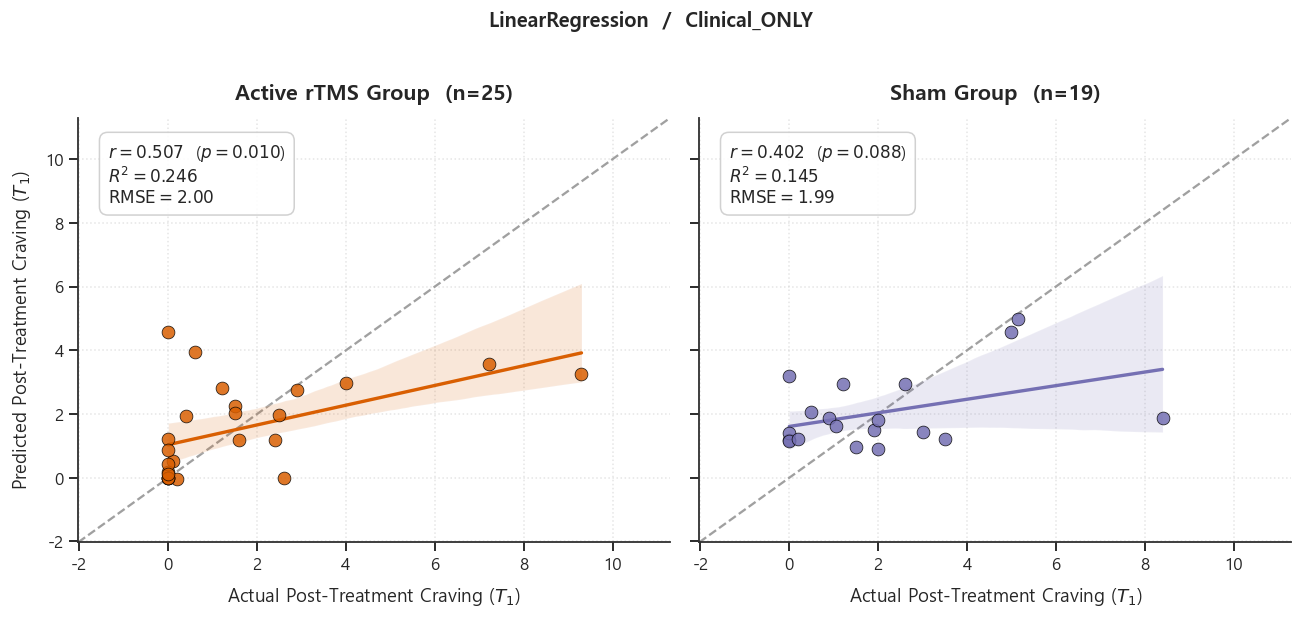

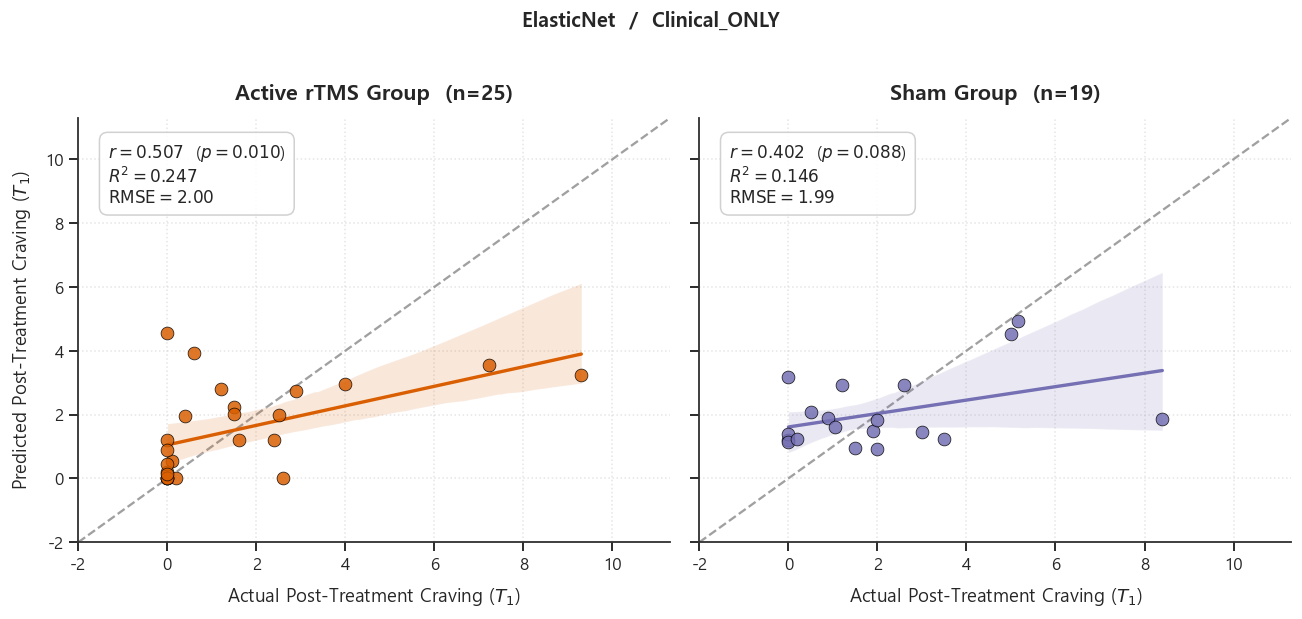

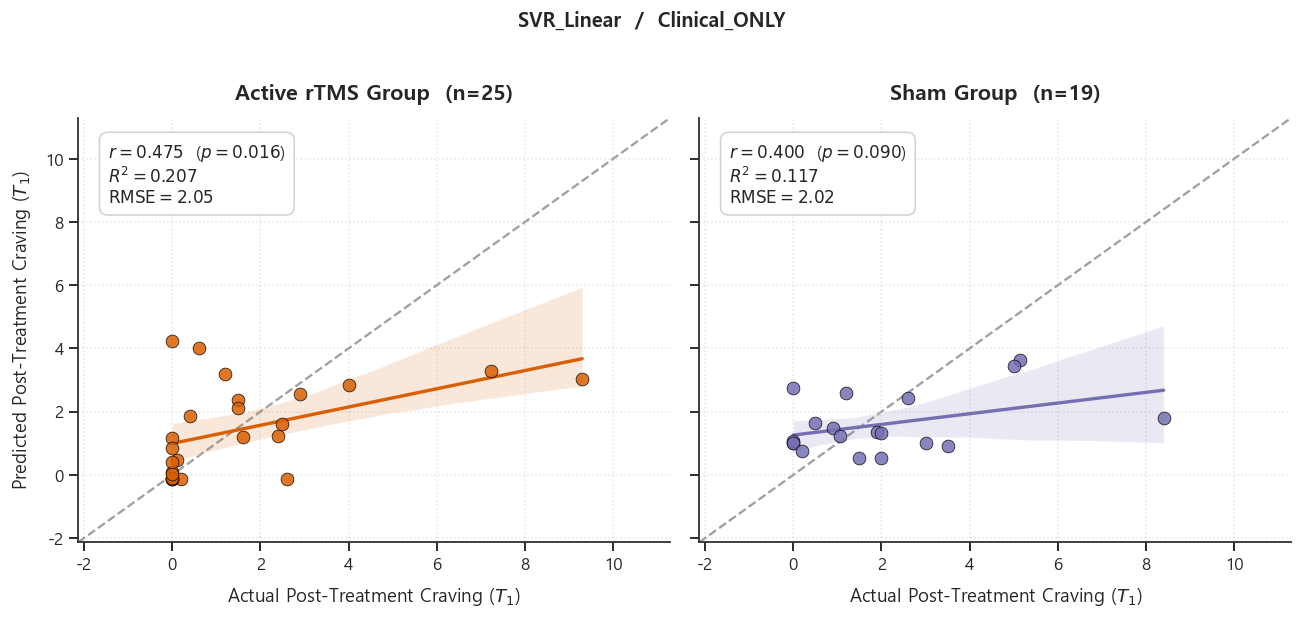

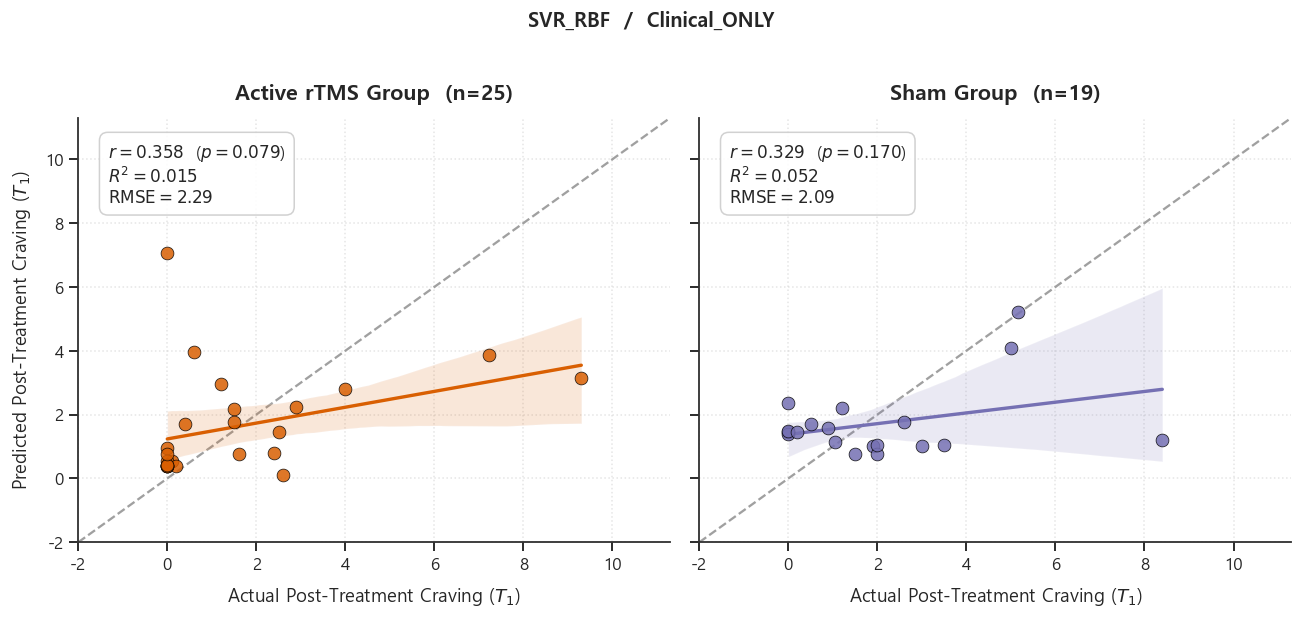

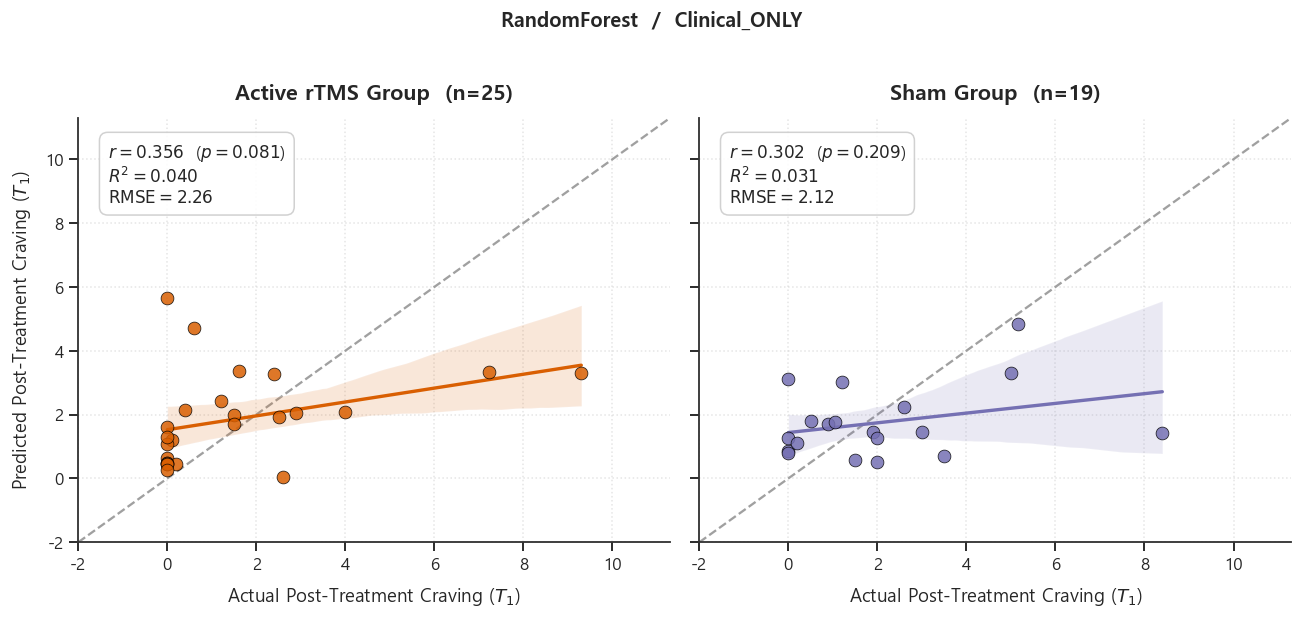

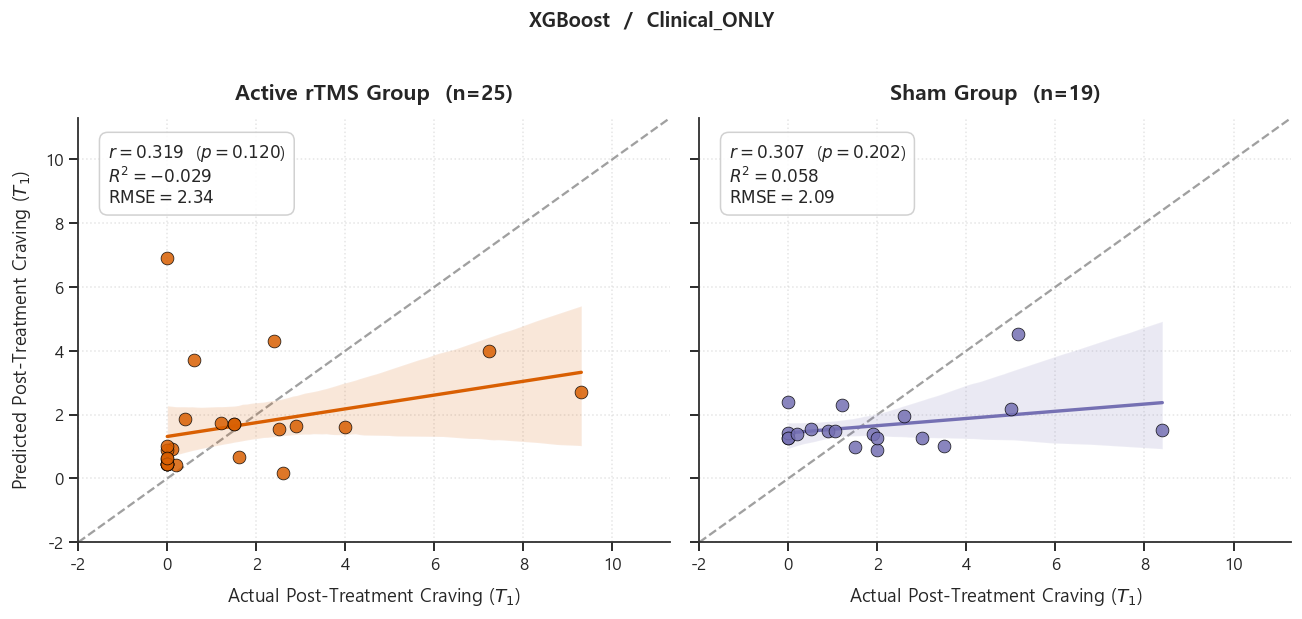

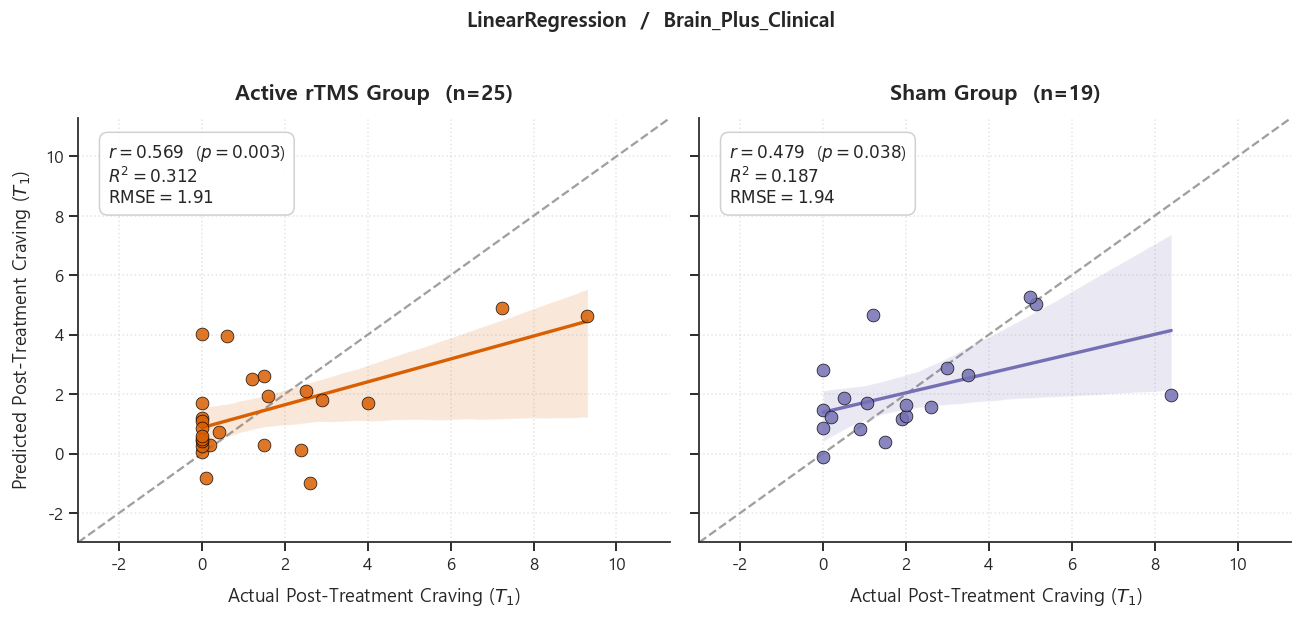

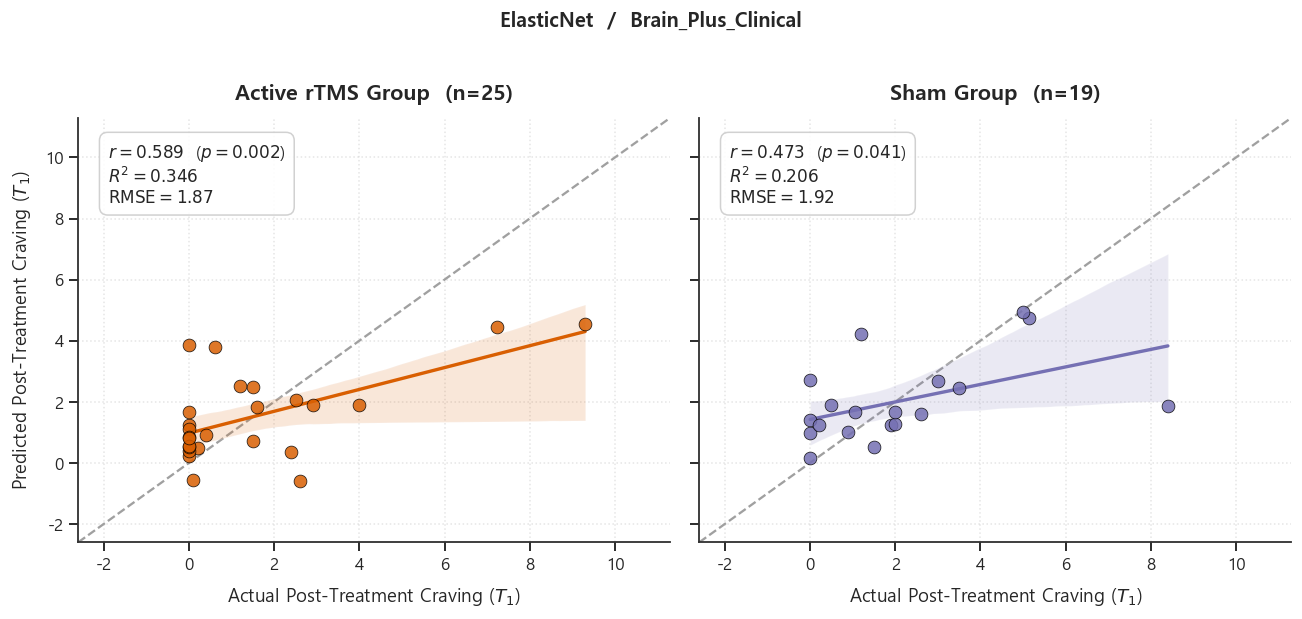

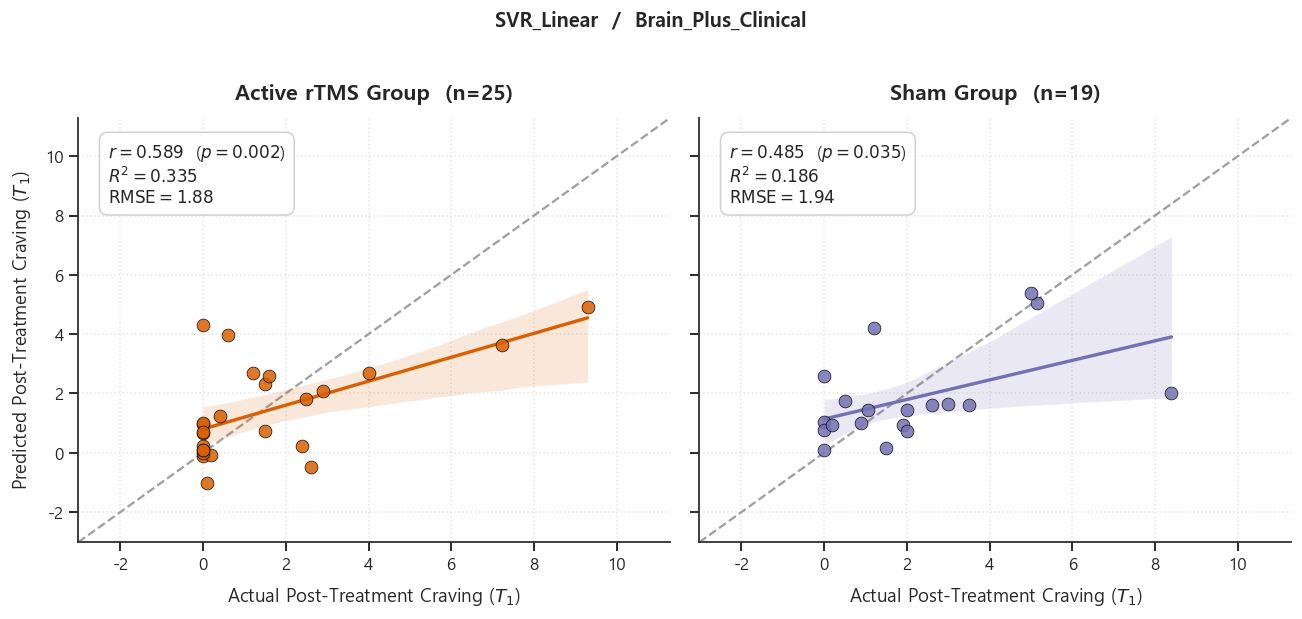

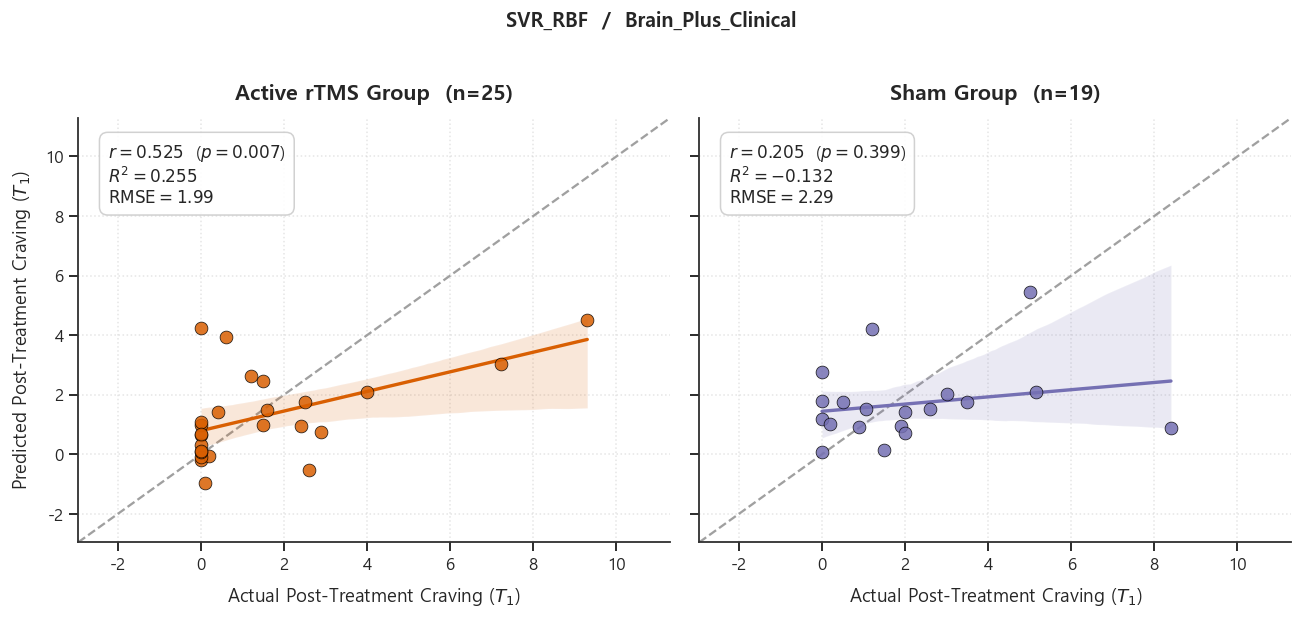

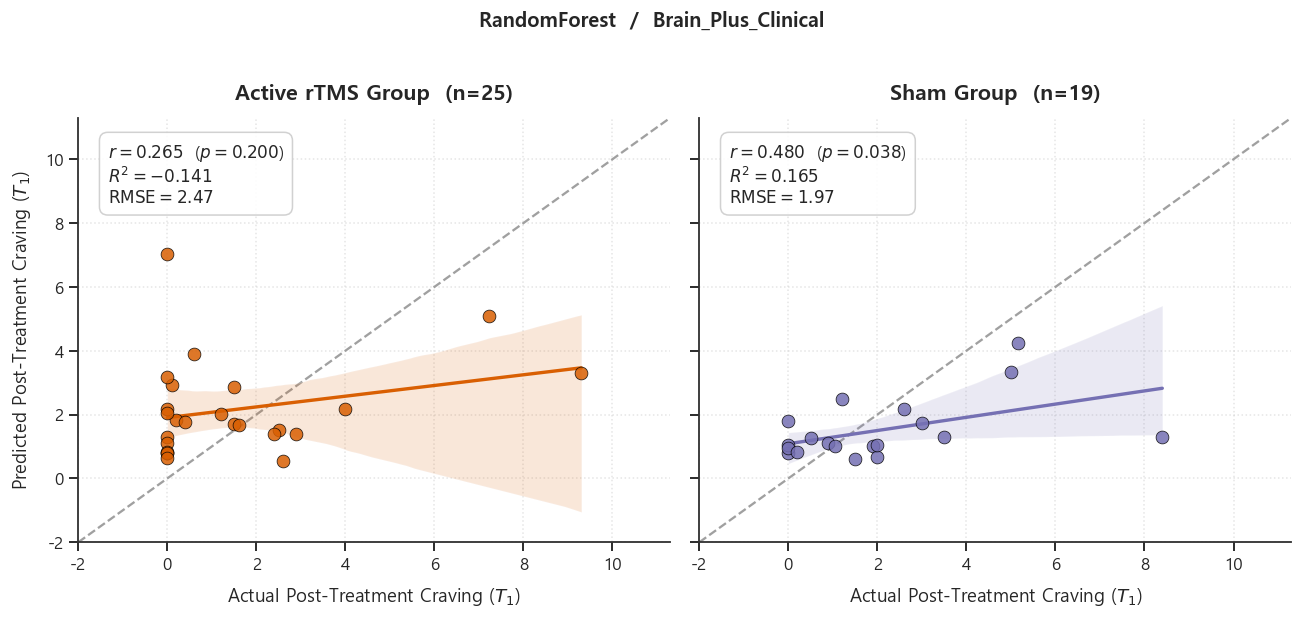

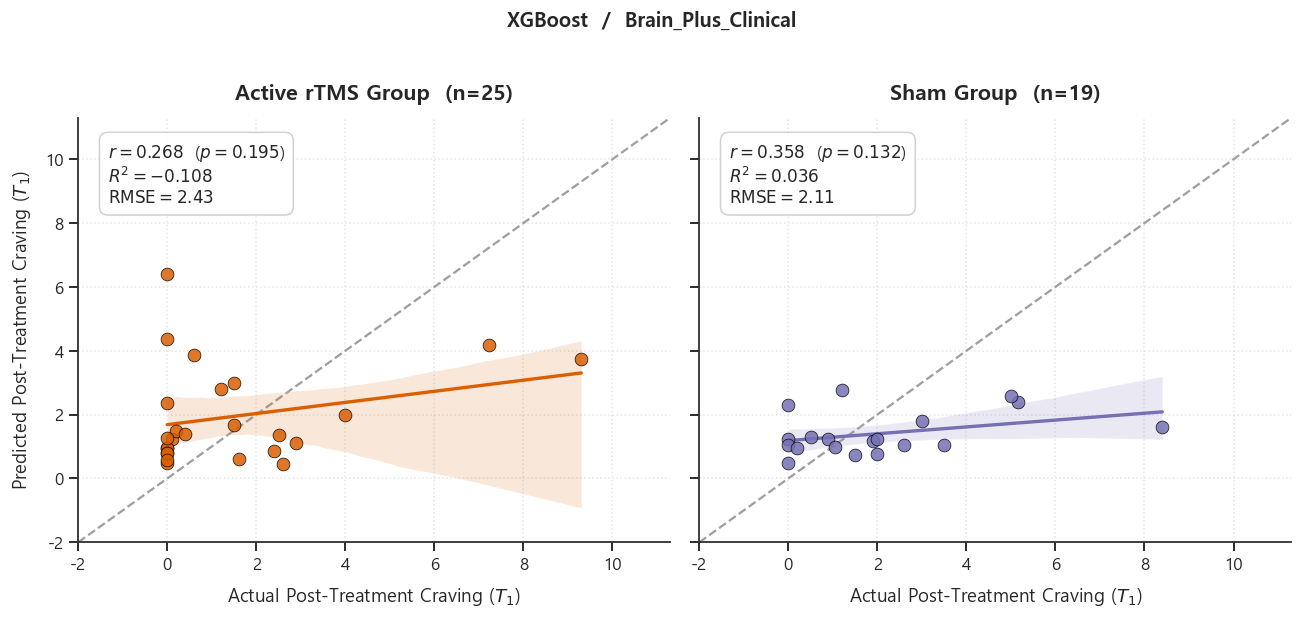

In [28]:
# ==========================================================
# 9. Active vs Sham — 12세트 전부
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'   # Helvetica는 Windows에 없음
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving'])**2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)

        sns.scatterplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            color=color, s=70, alpha=0.85, edgecolor='black',
            linewidth=0.5, ax=ax, zorder=3
        )

        sns.regplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
        )

        ax.set_title(f'{grp} Group  (n={len(sub_df)})',
                     fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(
            0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='#CCCCCC')
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [29]:
# ==========================================================
# 10. 군간 아티팩트 점검 — vas 분산 / 상관 구조가 다른가
# ==========================================================
from scipy.stats import levene

g = df['treatment_group'].values
vt0, vt1 = df['vas_t0'].values, df['vas_t1'].values

rows = []
for grp, code in [('Active', 2), ('Sham', 1)]:
    m = g == code
    r_raw, p_raw = pearsonr(vt0[m], vt1[m])
    rows.append({
        'group': grp, 'n': m.sum(),
        'vas_t0_mean': vt0[m].mean(), 'vas_t0_SD': vt0[m].std(ddof=1),
        'vas_t1_mean': vt1[m].mean(), 'vas_t1_SD': vt1[m].std(ddof=1),
        'r(t0,t1)': r_raw, 'p': p_raw
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

# 분산 동일성 (Levene)
for v, nm in [(vt0, 'vas_t0'), (vt1, 'vas_t1')]:
    W, p = levene(v[g == 2], v[g == 1])
    print(f"Levene {nm}: W={W:.3f}, p={p:.3f}")

 group  n  vas_t0_mean  vas_t0_SD  vas_t1_mean  vas_t1_SD  r(t0,t1)     p
Active 25        3.803      3.582        1.521      2.356     0.633 0.001
  Sham 19        2.628      2.903        2.047      2.210     0.491 0.033
Levene vas_t0: W=2.323, p=0.135
Levene vas_t1: W=0.019, p=0.890


# 11. Nodal strength vs VAS (t0, t1) — SHAP Top-2 개별 산점도

모델 예측값이 아니라 **raw nodal strength ↔ raw VAS**의 1:1 관계를 본다.
SHAP 상위 2개 뇌 피처(`rh_Pallidum_fc`, `lh_cuneus_fc`) x 2개 시점(`vas_t0`, `vas_t1`) = 4개 산점도, n=44 전원.

이 두 피처가 "이 뇌 지표를 보면 통증(VAS) 수준을 알 수 있다"는 biomarker 후보인지에 대한 가장 기본적인 확인 단계다.
(참고: 위 SHAP 피처들은 `vas_t1` 예측 모델에서 나온 것이므로 `vas_t1`과의 관계가 1차 관심사이고, `vas_t0`는 baseline 대조용이다.)

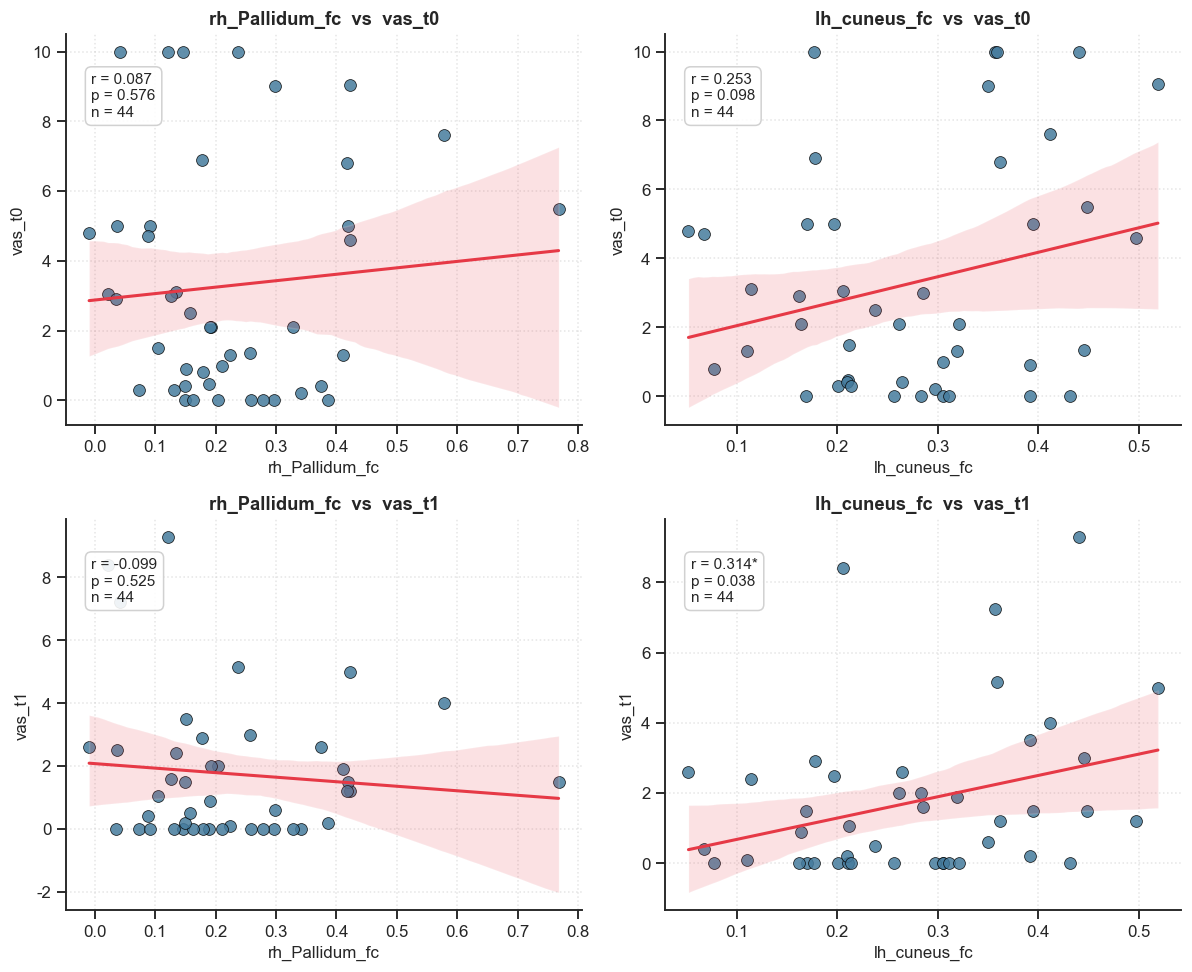

In [30]:
brain_feats_plot = ['rh_Pallidum_fc', 'lh_cuneus_fc']
vas_targets_plot = ['vas_t0', 'vas_t1']

plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 2, figsize=(11, 9), dpi=110)

for row, vas_col in enumerate(vas_targets_plot):
    for col, feat in enumerate(brain_feats_plot):
        ax = axes[row, col]
        x = df[feat].values
        y_v = df[vas_col].values

        r, pval = pearsonr(x, y_v)

        # scatter_kws는 ax.scatter로 넘어감 -> linewidth(X) / linewidths(O).
        # seaborn이 내부에서 linewidths를 setdefault 하므로 linewidth를 주면 alias 충돌 TypeError.
        sns.regplot(x=x, y=y_v, ax=ax, scatter_kws=dict(s=60, alpha=0.85, edgecolor='black',
                    linewidths=0.5, color='#457B9D'), line_kws=dict(color='#E63946', linewidth=2), ci=95)

        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel(vas_col, fontsize=11)
        ax.set_title(f'{feat}  vs  {vas_col}', fontsize=12, fontweight='bold')

        sig = '*' if pval < 0.05 else ''
        ax.text(0.05, 0.90, f'r = {r:.3f}{sig}\np = {pval:.3f}\nn = {len(x)}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

        ax.grid(True, linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

# Spearman

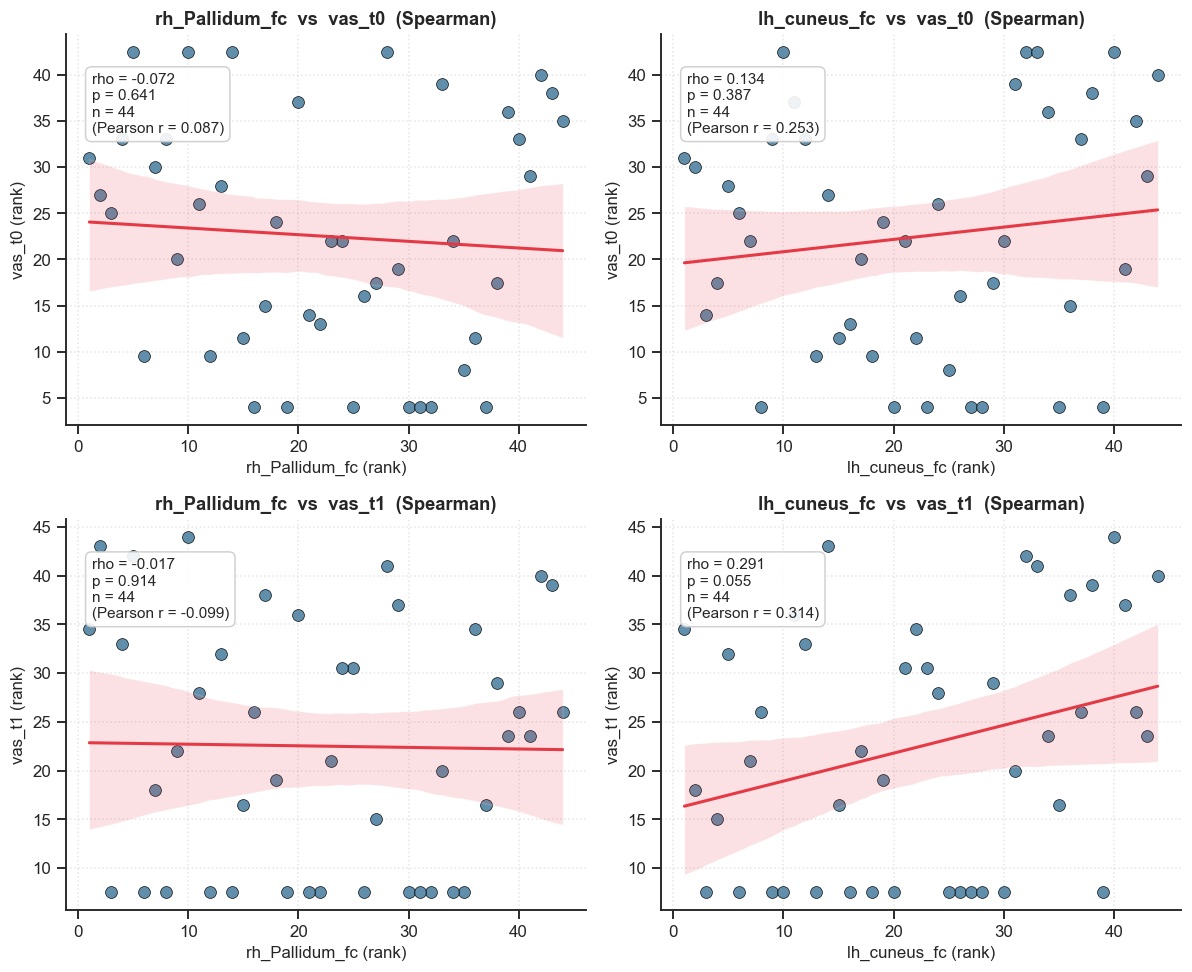

In [32]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(2, 2, figsize=(11, 9), dpi=110)

for row, vas_col in enumerate(vas_targets_plot):
    for col, feat in enumerate(brain_feats_plot):
        ax = axes[row, col]

        sub = df[[feat, vas_col]].dropna()
        x_raw = sub[feat].values
        y_raw = sub[vas_col].values

        rho, pval = spearmanr(x_raw, y_raw)
        r_p, p_p = pearsonr(x_raw, y_raw)

        x_rank = pd.Series(x_raw).rank().values
        y_rank = pd.Series(y_raw).rank().values

        sns.regplot(x=x_rank, y=y_rank, ax=ax,
                    scatter_kws=dict(s=60, alpha=0.85, edgecolor='black',
                                     linewidths=0.5, color='#457B9D'),
                    line_kws=dict(color='#E63946', linewidth=2), ci=95)

        ax.set_xlabel(f'{feat} (rank)', fontsize=11)
        ax.set_ylabel(f'{vas_col} (rank)', fontsize=11)
        ax.set_title(f'{feat}  vs  {vas_col}  (Spearman)', fontsize=12, fontweight='bold')

        sig = '*' if pval < 0.05 else ''
        ax.text(0.05, 0.90,
                f'rho = {rho:.3f}{sig}\np = {pval:.3f}\nn = {len(sub)}\n(Pearson r = {r_p:.3f})',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

        ax.grid(True, linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

# 12. Nodal strength vs VAS — Active rTMS vs Sham 분리

위 4개 산점도를 `treatment_group`(Active rTMS / Sham)으로 나눠서 다시 본다.
군마다 관계의 방향/강도가 다르면, 전체 44명을 합친 상관은 두 군이 섞여 상쇄되거나 과장된 것일 수 있다.
(9번 섹션의 Active/Sham 분리 방식과 동일한 포맷.)

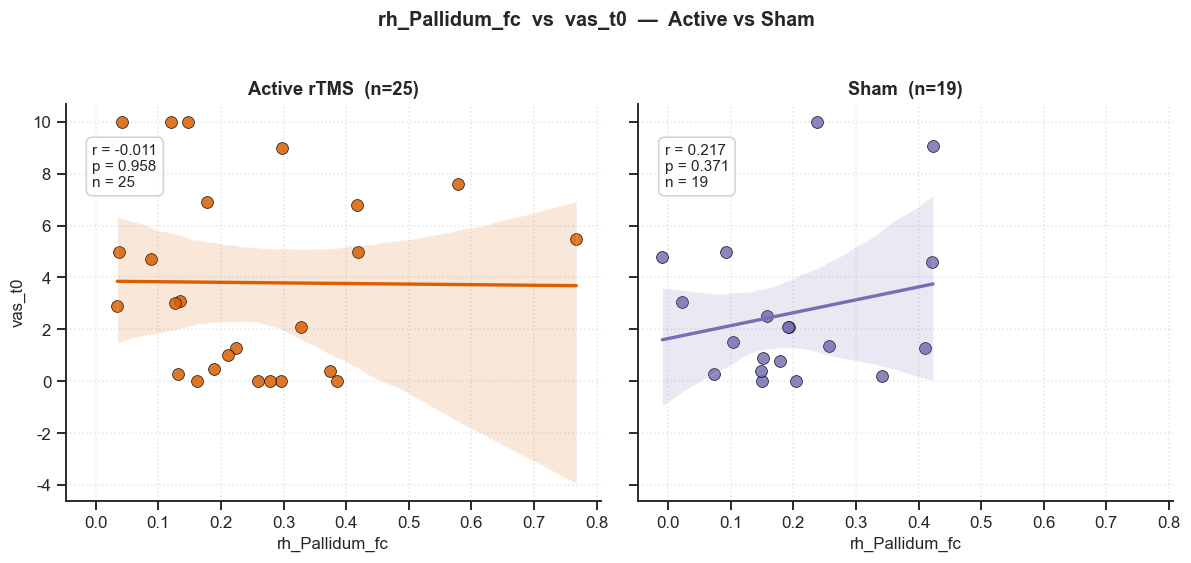

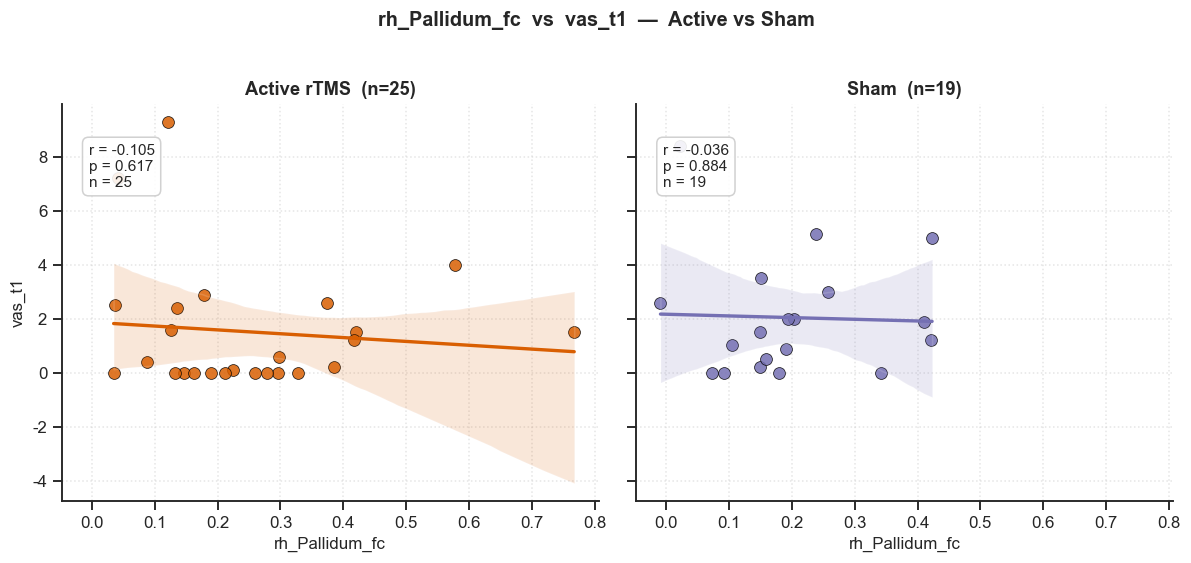

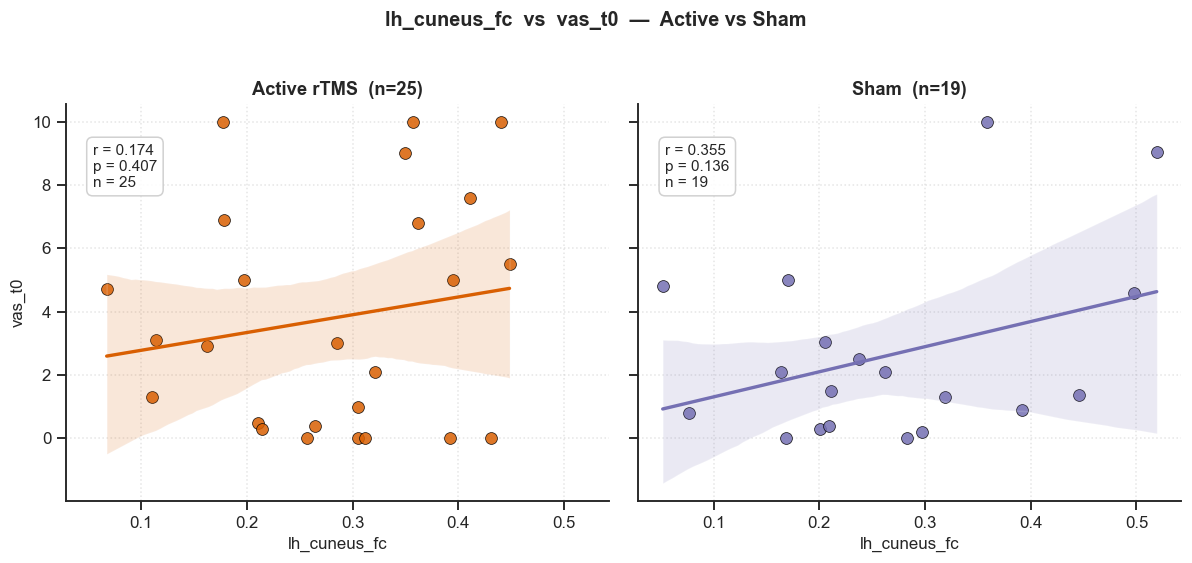

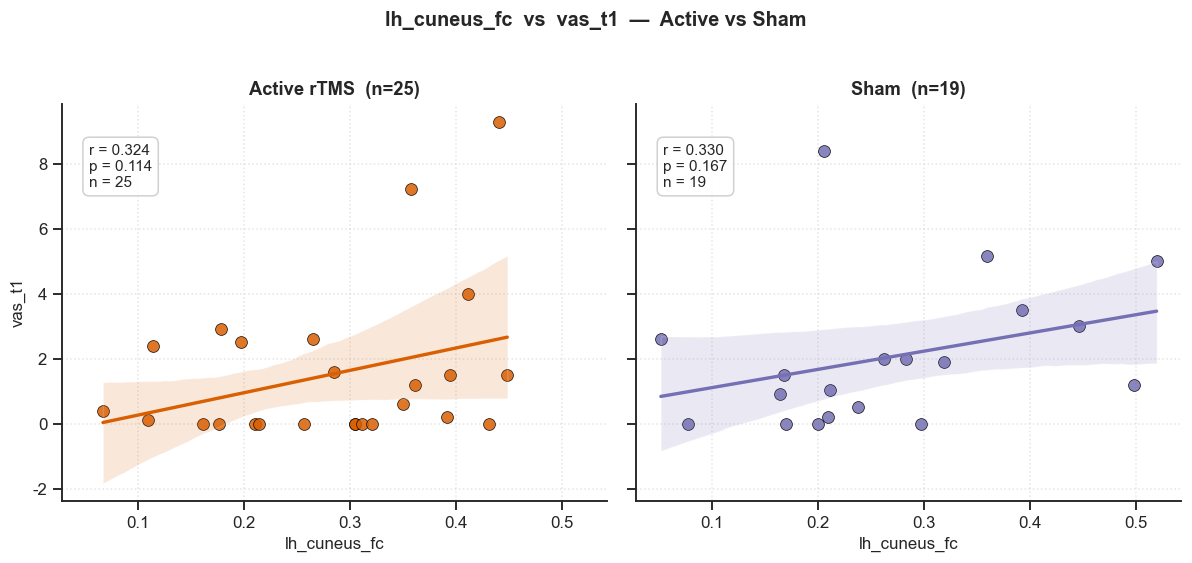

In [33]:
palette2 = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups2 = ['Active rTMS', 'Sham']
group_labels = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for feat in brain_feats_plot:
    for vas_col in vas_targets_plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=110, sharex=True, sharey=True)

        for i, grp in enumerate(groups2):
            ax = axes[i]
            mask = group_labels == grp
            x = df.loc[mask, feat].values
            y_v = df.loc[mask, vas_col].values
            color = palette2[grp]

            r, pval = pearsonr(x, y_v)

            sns.regplot(x=x, y=y_v, ax=ax,
                        scatter_kws=dict(s=60, alpha=0.85, edgecolor='black', linewidths=0.5, color=color),
                        line_kws=dict(color=color, linewidth=2.2), ci=95)

            ax.set_title(f'{grp}  (n={mask.sum()})', fontsize=12, fontweight='bold')
            ax.set_xlabel(feat, fontsize=11)
            if i == 0:
                ax.set_ylabel(vas_col, fontsize=11)

            sig = '*' if pval < 0.05 else ''
            ax.text(0.05, 0.90, f'r = {r:.3f}{sig}\np = {pval:.3f}\nn = {mask.sum()}',
                    transform=ax.transAxes, fontsize=10, va='top',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

            ax.grid(True, linestyle=':', alpha=0.5)

        fig.suptitle(f'{feat}  vs  {vas_col}  —  Active vs Sham', fontsize=13, fontweight='bold', y=1.02)
        sns.despine()
        plt.tight_layout()
        plt.show()